In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [14]:
# 1) зчитування; одразу трактуємо '?' як пропуски й ігноруємо пробіли після ком
df = pd.read_csv(
    "data/adult.csv",
    na_values=["?"],
    skipinitialspace=True
)

# 2) прибираємо зайві пробіли в текстових колонках
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

# 3) дропаємо будь-які рядки, де зустрівся '?'/NaN
df = df.dropna().reset_index(drop=True)

# 4) (опційно) перевірка цілісності salary та salary $K, якщо такі є
salary_cols = {"salary", "salary $K"}
if salary_cols.issubset(df.columns):
    # вилучаємо символи $, K, коми, тощо і перетворюємо на float
    df["salary"] = (
        df["salary"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True).astype(float)
    )
    df["salary $K"] = (
        df["salary $K"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True).astype(float)
    )

    # очікуємо, що salary $K == salary / 1000
    ok_mask = np.isclose(df["salary"] / 1000.0, df["salary $K"], rtol=1e-6, atol=1e-6)
    n_bad = (~ok_mask).sum()

    print(f"Rows checked: {len(df)}; inconsistencies in salary vs salary $K: {n_bad}")
    if n_bad:
        display(df.loc[~ok_mask, ["salary", "salary $K"]].head())

# 5) готовий очищений датафрейм:
df.head()


,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
0,0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,39
1,1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,35
2,2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,27
3,3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,43
4,4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,25


# Task 1
Print the count of men and women in the dataset.

In [15]:
men = (df["sex"] == "Male").sum()
women = (df["sex"] == "Female").sum()

print("Men:", men)
print("Women:", women)

Men: 20380
Women: 9782


# Task 2
Find the average age of men in dataset

In [16]:
avg_age_men = df.loc[df["sex"] == "Male", "age"].mean()

print("Average age of men:", avg_age_men)

Average age of men: 39.18400392541707


# Task 3
Get the percentage of people from Poland (native-country)

In [17]:
pct_poland = (df["native-country"].eq("Poland").mean()) * 100
print(f"Percentage of people from Poland: {pct_poland:.2f}%")

Percentage of people from Poland: 0.19%


# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [18]:
high_income = df[df["salary"] == ">50K"]["age"]
low_income = df[df["salary"] == "<=50K"]["age"]

print("Age stats for >50K:")
print("Mean:", high_income.mean())
print("Std:", high_income.std())

print("\nAge stats for <=50K:")
print("Mean:", low_income.mean())
print("Std:", low_income.std())

Age stats for >50K:
Mean: 43.95911028236548
Std: 10.269632835673852

Age stats for <=50K:
Mean: 36.60806038668668
Std: 13.464631257161633


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [19]:
higher_education = [
    "Bachelors",
    "Prof-school",
    "Assoc-acdm",
    "Assoc-voc",
    "Masters",
    "Doctorate"
]

# Люди з >50K, але без вищої освіти
people_no_higher_but_rich = df[
    (~df["education"].isin(higher_education)) & (df["salary"] == ">50K")
]

count = len(people_no_higher_but_rich)

print("People without higher education but earning >50K:", count)


People without higher education but earning >50K: 3178


# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [20]:
age_stats_by_education = df.groupby("education")["age"].describe()

# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [21]:
men = df.loc[df["sex"] == "Male"].copy()

men["is_married"] = men["marital-status"].str.startswith("Married")

salary_stats = (
    men.groupby("is_married")["salary"]
      .value_counts(normalize=True)
      .rename("percentage")
      .mul(100)
      .reset_index()
)

salary_stats

,is_married,salary,percentage
0,False,<=50K,91.150559
1,False,>50K,8.849441
2,True,<=50K,55.201566
3,True,>50K,44.798434


# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [22]:
max_hours = df["hours-per-week"].max()
n_people = (df["hours-per-week"] == max_hours).sum()

print("Max hours per week:", max_hours)
print("Number of people who work that many hours:", n_people)

Max hours per week: 99
Number of people who work that many hours: 78


# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

age ↔ salary K$: correlation = 0.208 (positive)
hours-per-week ↔ salary K$: correlation = 0.196 (positive)
age ↔ hours-per-week: correlation = 0.102 (positive)
Unnamed: 0 ↔ hours-per-week: correlation = -0.002 (negative)
Unnamed: 0 ↔ age: correlation = -0.001 (negative)
Unnamed: 0 ↔ salary K$: correlation = 0.000 (positive)


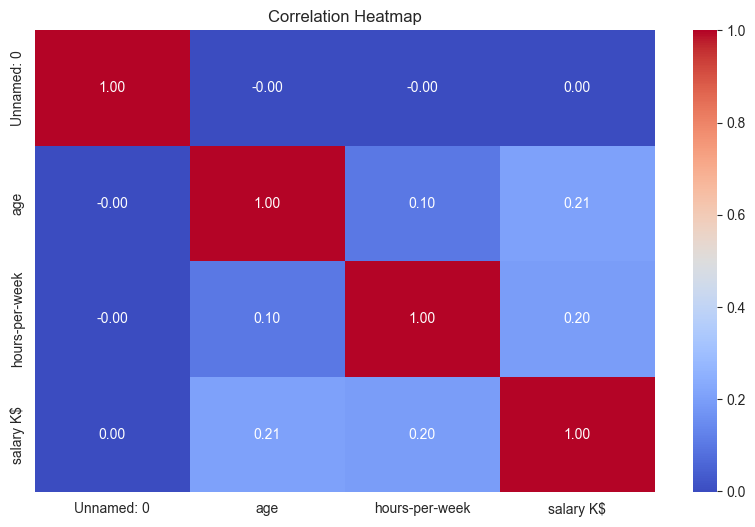

In [23]:
num_df = df.select_dtypes(include="number")
corr_matrix = num_df.corr()

corr_matrix

corr_pairs = (
    corr_matrix.unstack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# прибираємо self-correlation
corr_pairs = corr_pairs[corr_pairs["feature_1"] != corr_pairs["feature_2"]]

# унікальні пари (щоб не дублювались A-B і B-A)
corr_pairs["pair"] = corr_pairs.apply(lambda r: tuple(sorted([r["feature_1"], r["feature_2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates("pair")

# сортуємо за силою зв’язку
top_corr = corr_pairs.reindex(corr_pairs["correlation"].abs().sort_values(ascending=False).index)

top_corr.head(10)

for _, row in top_corr.head(8).iterrows():
    f1, f2, corr = row["feature_1"], row["feature_2"], row["correlation"]
    direction = "positive" if corr > 0 else "negative"
    print(f"{f1} ↔ {f2}: correlation = {corr:.3f} ({direction})")
    
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()    